<a href="https://colab.research.google.com/github/Darkkavn/CNN_VisionTransfromer_On_PathMNIST/blob/main/notebooks/PathMNIST_CNN_ViT_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân loại mô bệnh học bằng CNN và Vision Transformer trên PathMNIST

**Tiểu luận thạc sĩ — Deep Learning**

| | |
|---|---|
| **Dataset** | PathMNIST (MedMNIST v2) — 107,180 ảnh mô đại trực tràng, 9 lớp |
| **Mô hình** | CNN baseline · ResNet18 (transfer learning) · Vision Transformer (ViT) |
| **Framework** | PyTorch |

---
### Hướng dẫn sử dụng
1. **Runtime → Change runtime type → T4 GPU**  
2. Chạy từ đầu đến cuối: **Runtime → Run all**  
3. Kết quả tự động lưu vào Google Drive (`/content/drive/MyDrive/PathMNIST_Results/`)


## 0. Cài đặt & Mount Google Drive

In [1]:
# Kiểm tra GPU
import torch
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.11.0+cu128
CUDA     : True
GPU      : Tesla T4
VRAM     : 15.6 GB


In [2]:
!pip install medmnist einops -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR   = '/content/drive/MyDrive/PathMNIST_Results'
CKPT_DIR    = f'{DRIVE_DIR}/checkpoints'
FIGURE_DIR  = f'{DRIVE_DIR}/figures'
RESULTS_DIR = f'{DRIVE_DIR}/results'
DATA_DIR    = '/content/data'

for d in [CKPT_DIR, FIGURE_DIR, RESULTS_DIR, DATA_DIR]:
    os.makedirs(d, exist_ok=True)

print('Thư mục sẵn sàng!')
print(f'  Checkpoints : {CKPT_DIR}')
print(f'  Figures     : {FIGURE_DIR}')

Mounted at /content/drive
Thư mục sẵn sàng!
  Checkpoints : /content/drive/MyDrive/PathMNIST_Results/checkpoints
  Figures     : /content/drive/MyDrive/PathMNIST_Results/figures


## 1. Import & Config

In [4]:
import random, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from einops import rearrange

import medmnist
from medmnist import PathMNIST, INFO
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# ── Config ────────────────────────────────────────────────────────
CFG = dict(
    seed        = 42,
    num_classes = 9,
    image_size  = 28,
    batch_size  = 128,       # T4 GPU chạy thoải mái
    num_workers = 2,
    epochs      = 30,
    lr          = 1e-3,
    weight_decay= 1e-4,
    patience    = 7,         # early stopping
)

# Pixel stats tính từ tập train PathMNIST
MEAN = (0.7406, 0.5331, 0.7059)
STD  = (0.2086, 0.2530, 0.2168)

CLASS_NAMES = [
    'Adipose', 'Background', 'Debris', 'Lymphocytes', 'Mucus',
    'Smooth Muscle', 'Normal Colon Mucosa',
    'Cancer-Assoc. Stroma', 'Colorectal Adenocarcinoma',
]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])
print('Config OK')

Device: cuda
Config OK


## 2. EDA — Khám phá Dataset PathMNIST

In [5]:
# ── Thông tin dataset ──────────────────────────────────────────────
info = INFO['pathmnist']
print('=' * 60)
print('PATHMNIST — THÔNG TIN DATASET')
print('=' * 60)
print(f"Task    : {info['task']}")
print(f"Kênh    : {info['n_channels']}  |  Kích thước: 28×28")
print(f"Số lớp  : {len(info['label'])}")
print(f"Phân chia: {info['n_samples']}")
print()
for k, v in info['label'].items():
    print(f"  [{k}] {v}")

PATHMNIST — THÔNG TIN DATASET
Task    : multi-class
Kênh    : 3  |  Kích thước: 28×28
Số lớp  : 9
Phân chia: {'train': 89996, 'val': 10004, 'test': 7180}

  [0] adipose
  [1] background
  [2] debris
  [3] lymphocytes
  [4] mucus
  [5] smooth muscle
  [6] normal colon mucosa
  [7] cancer-associated stroma
  [8] colorectal adenocarcinoma epithelium


In [6]:
# ── Tải dataset thô (không transform) để EDA ──────────────────────
raw_train = PathMNIST(split='train', download=True, root=DATA_DIR, size=28)
raw_val   = PathMNIST(split='val',   download=True, root=DATA_DIR, size=28)
raw_test  = PathMNIST(split='test',  download=True, root=DATA_DIR, size=28)

tr_imgs, tr_lbls = raw_train.imgs, raw_train.labels.flatten()
vl_imgs, vl_lbls = raw_val.imgs,   raw_val.labels.flatten()
te_imgs, te_lbls = raw_test.imgs,  raw_test.labels.flatten()

print(f'Train : {len(tr_imgs):,}')
print(f'Val   : {len(vl_imgs):,}')
print(f'Test  : {len(te_imgs):,}')

100%|██████████| 206M/206M [00:11<00:00, 17.7MB/s]


Train : 89,996
Val   : 10,004
Test  : 7,180


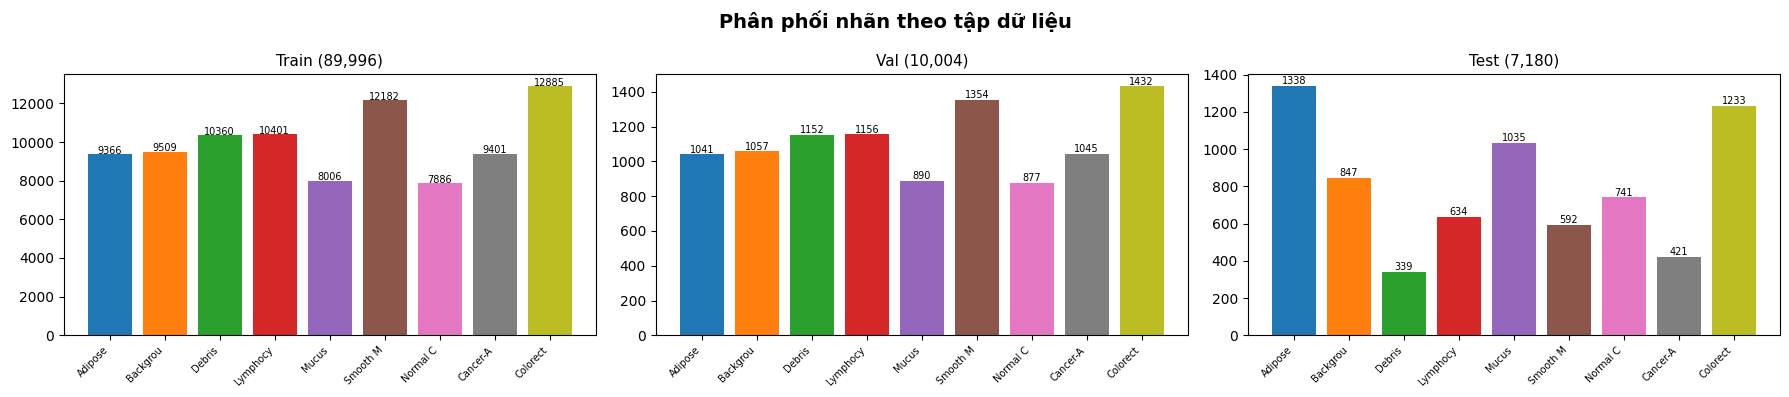


ID   Tên lớp                          Train    Val   Test  %Train
----------------------------------------------------------
0    Adipose                          9,366  1,041  1,338   10.4%
1    Background                       9,509  1,057    847   10.6%
2    Debris                          10,360  1,152    339   11.5%
3    Lymphocytes                     10,401  1,156    634   11.6%
4    Mucus                            8,006    890  1,035    8.9%
5    Smooth Muscle                   12,182  1,354    592   13.5%
6    Normal Colon Mucosa              7,886    877    741    8.8%
7    Cancer-Assoc. Stroma             9,401  1,045    421   10.4%
8    Colorectal Adenocarcinoma       12,885  1,432  1,233   14.3%


In [7]:
# ── Phân phối nhãn ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Phân phối nhãn theo tập dữ liệu', fontsize=14, fontweight='bold')

for ax, (lbls, title) in zip(axes, [
    (tr_lbls, f'Train ({len(tr_imgs):,})'),
    (vl_lbls, f'Val ({len(vl_imgs):,})'),
    (te_lbls, f'Test ({len(te_imgs):,})'),
]):
    cnt = Counter(lbls)
    vals = [cnt[i] for i in range(9)]
    bars = ax.bar(range(9), vals, color=plt.cm.tab10.colors[:9])
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(9))
    ax.set_xticklabels([c[:8] for c in CLASS_NAMES], rotation=45, ha='right', fontsize=7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(v), ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Bảng thống kê
tr_cnt = Counter(tr_lbls)
print(f"\n{'ID':<4} {'Tên lớp':<30} {'Train':>7} {'Val':>6} {'Test':>6} {'%Train':>7}")
print('-' * 58)
for i, name in enumerate(CLASS_NAMES):
    tr = tr_cnt[i]; vl = Counter(vl_lbls)[i]; te = Counter(te_lbls)[i]
    print(f"{i:<4} {name:<30} {tr:>7,} {vl:>6,} {te:>6,} {tr/len(tr_lbls)*100:>6.1f}%")

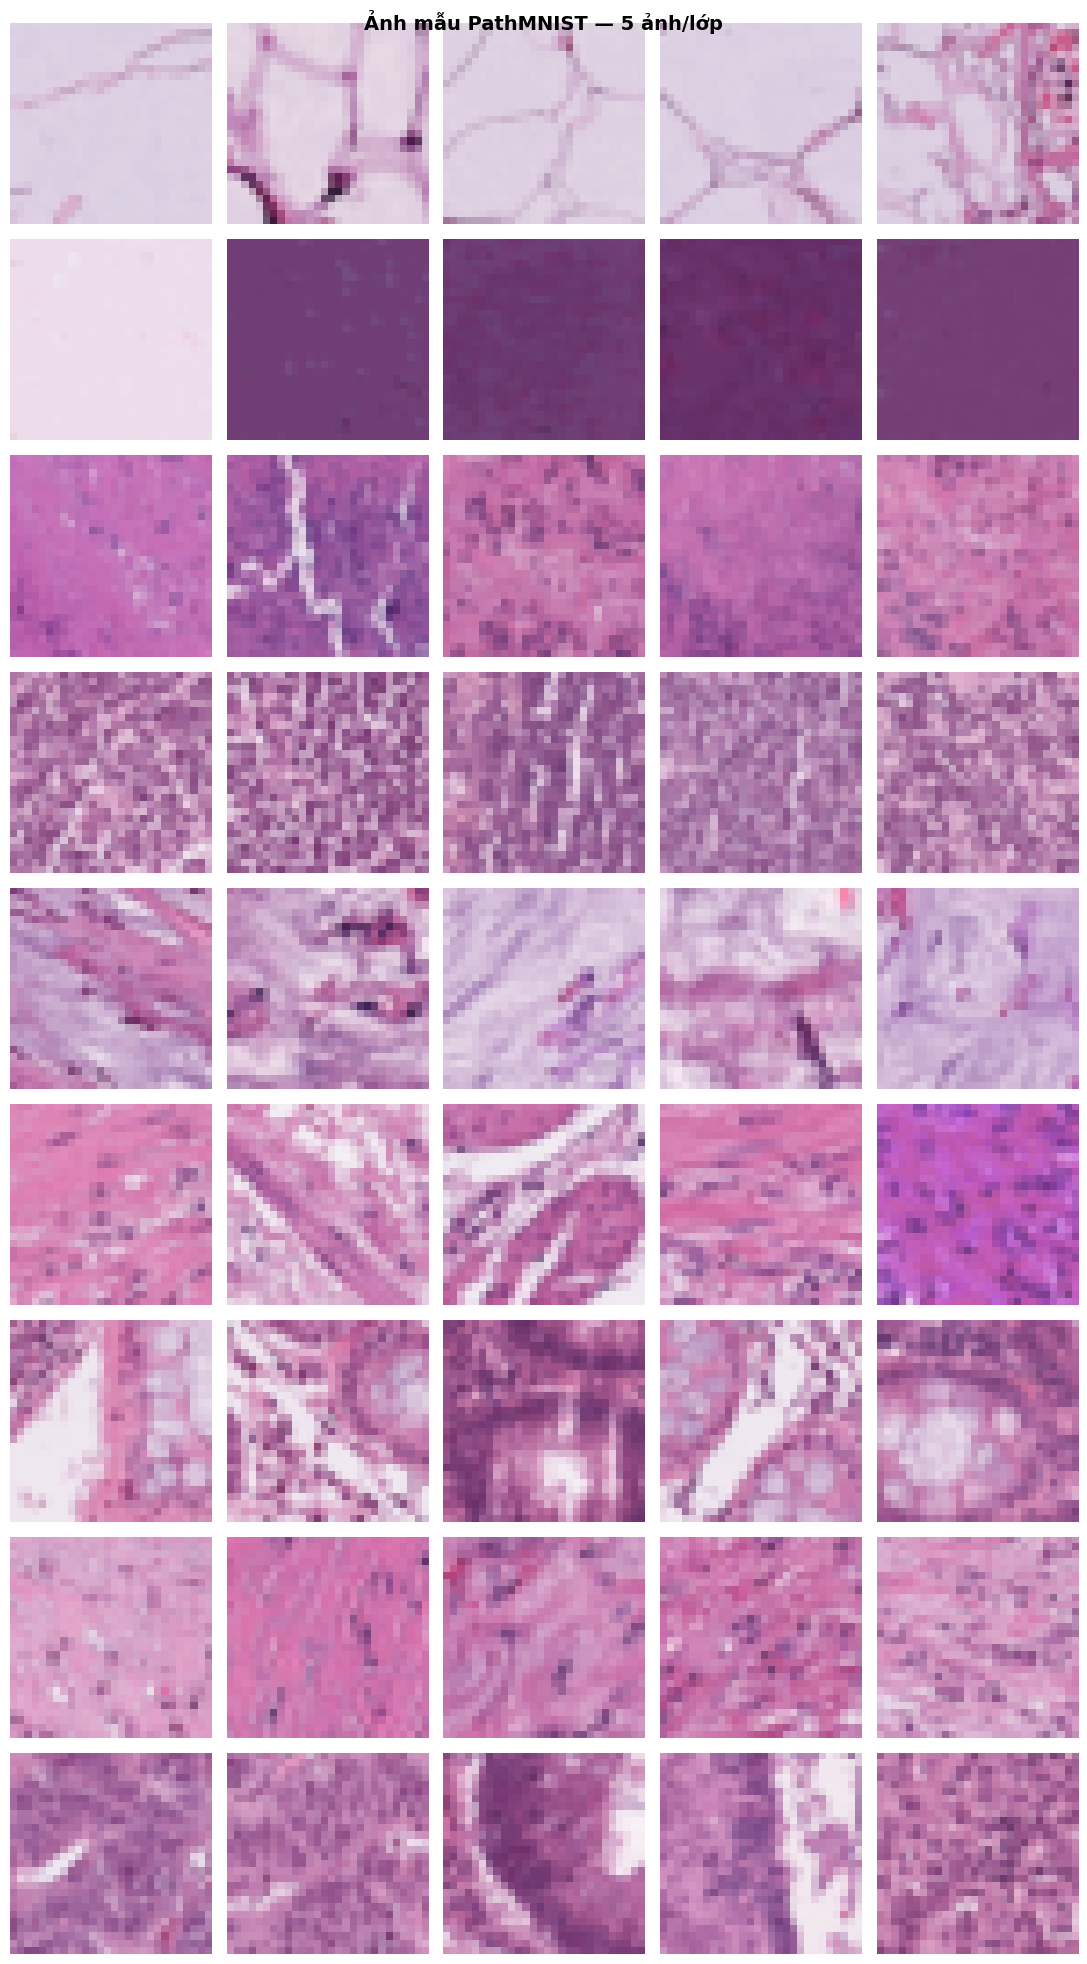

In [8]:
# ── Ảnh mẫu mỗi lớp ──────────────────────────────────────────────
fig, axes = plt.subplots(9, 5, figsize=(11, 20))
fig.suptitle('Ảnh mẫu PathMNIST — 5 ảnh/lớp', fontsize=14, fontweight='bold')

for cls_id in range(9):
    idx_list = np.where(tr_lbls == cls_id)[0][:5]
    for col, idx in enumerate(idx_list):
        ax = axes[cls_id][col]
        ax.imshow(tr_imgs[idx])
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f"{cls_id}:{CLASS_NAMES[cls_id][:14]}",
                          fontsize=7.5, rotation=0, labelpad=85, va='center')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Mean (R,G,B): 0.2378, 0.2378, 0.2378
Std  (R,G,B): 0.3581, 0.3089, 0.3522


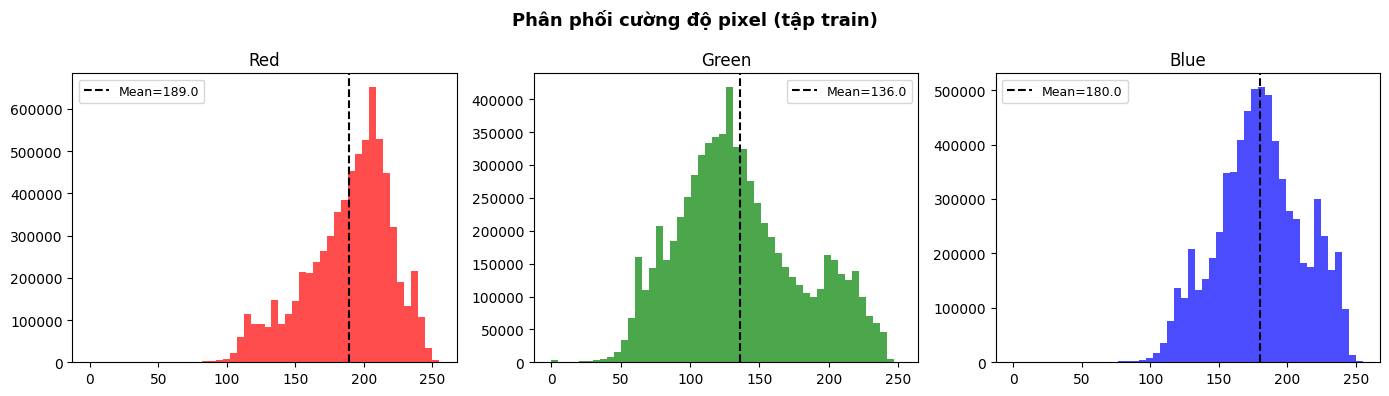

In [9]:
# ── Phân phối pixel ───────────────────────────────────────────────
imgs_f = tr_imgs.astype(np.float32) / 255.0
mean   = imgs_f.mean(axis=(0,1,2))
std    = imgs_f.std(axis=(0,1,2))
print(f'Mean (R,G,B): {mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}')
print(f'Std  (R,G,B): {std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Phân phối cường độ pixel (tập train)', fontsize=13, fontweight='bold')
for ch, (ax, col) in enumerate(zip(axes, ['red','green','blue'])):
    sample = tr_imgs[::10, :, :, ch].flatten()
    ax.hist(sample, bins=50, color=col, alpha=0.7)
    ax.axvline(sample.mean(), color='black', linestyle='--', label=f'Mean={sample.mean():.1f}')
    ax.set_title(['Red','Green','Blue'][ch]); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. DataLoader

In [10]:
def get_transforms(split):
    normalize = transforms.Normalize(mean=MEAN, std=STD)
    if split == 'train':
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            normalize,
        ])
    return transforms.Compose([transforms.ToTensor(), normalize])


def get_dataloaders():
    train_ds = PathMNIST(split='train', transform=get_transforms('train'),
                         download=True, root=DATA_DIR, size=CFG['image_size'])
    val_ds   = PathMNIST(split='val',   transform=get_transforms('val'),
                         download=True, root=DATA_DIR, size=CFG['image_size'])
    test_ds  = PathMNIST(split='test',  transform=get_transforms('test'),
                         download=True, root=DATA_DIR, size=CFG['image_size'])

    kw = dict(num_workers=CFG['num_workers'], pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, **kw)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_dataloaders()
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 704 | Val: 79 | Test: 57


## 4. Định nghĩa mô hình
### 4.1 CNN Baseline

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class SimpleCNN(nn.Module):
    """
    Input : (B, 3, 28, 28)
    Block1: 3→32,  pool → 14×14
    Block2: 32→64, pool →  7×7
    Block3: 64→128, no pool
    GAP → FC(128→256) → FC(256→9)
    """
    def __init__(self, num_classes=9, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=False),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))

# Test
m = SimpleCNN(); x = torch.zeros(2, 3, 28, 28)
print(f'CNN output: {m(x).shape}  | Params: {sum(p.numel() for p in m.parameters()):,}')

CNN output: torch.Size([2, 9])  | Params: 128,809


### 4.2 ResNet18 (Transfer Learning)

In [12]:
class ResNet18PathMNIST(nn.Module):
    """
    ResNet18 pretrained ImageNet → fine-tune toàn bộ.
    Thay FC cuối: 512 → num_classes.
    """
    def __init__(self, num_classes=9, pretrained=True):
        super().__init__()
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet18(weights=weights)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.model = backbone
    def forward(self, x): return self.model(x)

m = ResNet18PathMNIST()
print(f'ResNet18 output: {m(x).shape}  | Params: {sum(p.numel() for p in m.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


ResNet18 output: torch.Size([2, 9])  | Params: 11,181,129


### 4.3 Vision Transformer (ViT)

In [13]:
class PatchEmbedding(nn.Module):
    """Chia ảnh 28×28 thành 49 patches (4×4), project lên embed_dim."""
    def __init__(self, image_size=28, patch_size=4, in_ch=3, embed_dim=128):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)                            # (B, embed_dim, H/P, W/P)
        return rearrange(x, 'b c h w -> b (h w) c') # (B, num_patches, embed_dim)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden = embed_dim * mlp_ratio
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        res = x; x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + res
        return x + self.ff(self.norm2(x))


class VisionTransformer(nn.Module):
    """
    ViT từ đầu cho ảnh 28×28.
    patch_size=4 → 49 patches + 1 CLS token = sequence length 50.
    """
    def __init__(self, image_size=28, patch_size=4, in_ch=3, num_classes=9,
                 embed_dim=128, num_heads=4, num_layers=6, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_ch, embed_dim)
        n = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, n + 1, embed_dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x + self.pos_embed)
        x = self.blocks(x)
        return self.head(self.norm(x[:, 0]))

m = VisionTransformer()
print(f'ViT output: {m(x).shape}  | Params: {sum(p.numel() for p in m.parameters()):,}')

ViT output: torch.Size([2, 9])  | Params: 1,203,849


## 5. Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.squeeze(1).long().to(DEVICE)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += images.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate_loop(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.squeeze(1).long().to(DEVICE)
        out    = model(images)
        loss   = criterion(out, labels)
        loss_sum += loss.item() * images.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += images.size(0)
    return loss_sum / total, correct / total


def train(model, model_name, epochs=None):
    epochs    = epochs or CFG['epochs']
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(),
                            lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc  = 0.0
    wait      = 0
    history   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    ckpt_path = f'{CKPT_DIR}/{model_name}_best.pth'

    print(f'\n{"="*55}')
    print(f'  TRAINING: {model_name.upper()}')
    print(f'{"="*55}')
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate_loop(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        flag = ''
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), ckpt_path)
            wait = 0; flag = ' ★'
        else:
            wait += 1

        print(f'  [{epoch:2d}/{epochs}] '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f}  '
              f'Acc {tr_acc:.4f}/{vl_acc:.4f}{flag}')

        if wait >= CFG['patience']:
            print(f'  Early stopping tại epoch {epoch}')
            break

    elapsed = (time.time() - t0) / 60
    print(f'\n  Best Val Acc : {best_acc:.4f}')
    print(f'  Thời gian   : {elapsed:.1f} phút')
    print(f'  Checkpoint  : {ckpt_path}')
    return history

print('Hàm training sẵn sàng!')

Hàm training sẵn sàng!


## 6. Train CNN Baseline

In [15]:
set_seed(CFG['seed'])
cnn_model   = SimpleCNN(num_classes=CFG['num_classes']).to(DEVICE)
cnn_history = train(cnn_model, 'cnn')


  TRAINING: CNN
  [ 1/30] Loss 0.7533/0.8256  Acc 0.7256/0.7298 ★
  [ 2/30] Loss 0.4652/0.3294  Acc 0.8334/0.8869 ★
  [ 3/30] Loss 0.3834/0.6183  Acc 0.8641/0.7962
  [ 4/30] Loss 0.3413/0.2757  Acc 0.8794/0.9033 ★
  [ 5/30] Loss 0.3115/0.3341  Acc 0.8895/0.8822
  [ 6/30] Loss 0.2813/0.1987  Acc 0.9026/0.9302 ★
  [ 7/30] Loss 0.2615/0.2107  Acc 0.9091/0.9293
  [ 8/30] Loss 0.2502/0.1705  Acc 0.9125/0.9435 ★
  [ 9/30] Loss 0.2328/0.2018  Acc 0.9183/0.9321
  [10/30] Loss 0.2220/0.1603  Acc 0.9233/0.9430
  [11/30] Loss 0.2095/0.1339  Acc 0.9277/0.9542 ★
  [12/30] Loss 0.2008/0.1404  Acc 0.9307/0.9512
  [13/30] Loss 0.1879/0.1638  Acc 0.9355/0.9463
  [14/30] Loss 0.1861/0.1232  Acc 0.9370/0.9556 ★
  [15/30] Loss 0.1769/0.1208  Acc 0.9397/0.9599 ★
  [16/30] Loss 0.1698/0.1152  Acc 0.9416/0.9609 ★
  [17/30] Loss 0.1620/0.1026  Acc 0.9438/0.9641 ★
  [18/30] Loss 0.1593/0.0997  Acc 0.9455/0.9676 ★
  [19/30] Loss 0.1502/0.0929  Acc 0.9490/0.9696 ★
  [20/30] Loss 0.1479/0.0985  Acc 0.9499/0.9686

## 7. Train ResNet18

In [16]:
set_seed(CFG['seed'])
resnet_model   = ResNet18PathMNIST(num_classes=CFG['num_classes'], pretrained=True).to(DEVICE)
resnet_history = train(resnet_model, 'resnet18')


  TRAINING: RESNET18
  [ 1/30] Loss 0.4742/0.4905  Acc 0.8326/0.8360 ★
  [ 2/30] Loss 0.3390/0.2591  Acc 0.8810/0.9119 ★
  [ 3/30] Loss 0.2868/0.2479  Acc 0.8982/0.9066
  [ 4/30] Loss 0.2499/0.2781  Acc 0.9123/0.9092
  [ 5/30] Loss 0.2568/0.2448  Acc 0.9113/0.9169 ★
  [ 6/30] Loss 0.2342/0.1803  Acc 0.9191/0.9391 ★
  [ 7/30] Loss 0.2003/0.1818  Acc 0.9301/0.9385
  [ 8/30] Loss 0.1868/0.2097  Acc 0.9344/0.9288
  [ 9/30] Loss 0.1720/0.1609  Acc 0.9398/0.9449 ★
  [10/30] Loss 0.1790/0.1651  Acc 0.9383/0.9433
  [11/30] Loss 0.1523/0.1442  Acc 0.9463/0.9508 ★
  [12/30] Loss 0.1393/0.1387  Acc 0.9504/0.9523 ★
  [13/30] Loss 0.1267/0.1646  Acc 0.9553/0.9479
  [14/30] Loss 0.1248/0.1753  Acc 0.9567/0.9437
  [15/30] Loss 0.1413/0.1271  Acc 0.9513/0.9573 ★
  [16/30] Loss 0.1009/0.1279  Acc 0.9638/0.9546
  [17/30] Loss 0.0930/0.1206  Acc 0.9671/0.9621 ★
  [18/30] Loss 0.0853/0.1179  Acc 0.9702/0.9599
  [19/30] Loss 0.0745/0.1183  Acc 0.9736/0.9598
  [20/30] Loss 0.0718/0.1133  Acc 0.9745/0.9636 

## 8. Train Vision Transformer

In [17]:
set_seed(CFG['seed'])
vit_model   = VisionTransformer(
    image_size=28, patch_size=4, num_classes=CFG['num_classes'],
    embed_dim=128, num_heads=4, num_layers=6, mlp_ratio=4, dropout=0.1
).to(DEVICE)
vit_history = train(vit_model, 'vit')


  TRAINING: VIT
  [ 1/30] Loss 0.8085/0.5311  Acc 0.7025/0.8144 ★
  [ 2/30] Loss 0.5075/0.4364  Acc 0.8177/0.8442 ★
  [ 3/30] Loss 0.4194/0.3472  Acc 0.8491/0.8723 ★
  [ 4/30] Loss 0.3714/0.3071  Acc 0.8663/0.8915 ★
  [ 5/30] Loss 0.3359/0.2687  Acc 0.8789/0.9023 ★
  [ 6/30] Loss 0.3029/0.2325  Acc 0.8911/0.9179 ★
  [ 7/30] Loss 0.2777/0.2382  Acc 0.9008/0.9151
  [ 8/30] Loss 0.2616/0.1969  Acc 0.9062/0.9307 ★
  [ 9/30] Loss 0.2374/0.1885  Acc 0.9151/0.9353 ★
  [10/30] Loss 0.2169/0.1788  Acc 0.9227/0.9423 ★
  [11/30] Loss 0.2012/0.1838  Acc 0.9288/0.9383
  [12/30] Loss 0.1885/0.1472  Acc 0.9329/0.9493 ★
  [13/30] Loss 0.1724/0.1366  Acc 0.9384/0.9546 ★
  [14/30] Loss 0.1618/0.1276  Acc 0.9436/0.9572 ★
  [15/30] Loss 0.1502/0.1194  Acc 0.9468/0.9588 ★
  [16/30] Loss 0.1371/0.1097  Acc 0.9514/0.9628 ★
  [17/30] Loss 0.1286/0.1030  Acc 0.9542/0.9660 ★
  [18/30] Loss 0.1185/0.0982  Acc 0.9579/0.9677 ★
  [19/30] Loss 0.1082/0.0928  Acc 0.9609/0.9707 ★
  [20/30] Loss 0.0991/0.0874  Acc 0.9

## 9. Vẽ Loss / Accuracy Curves

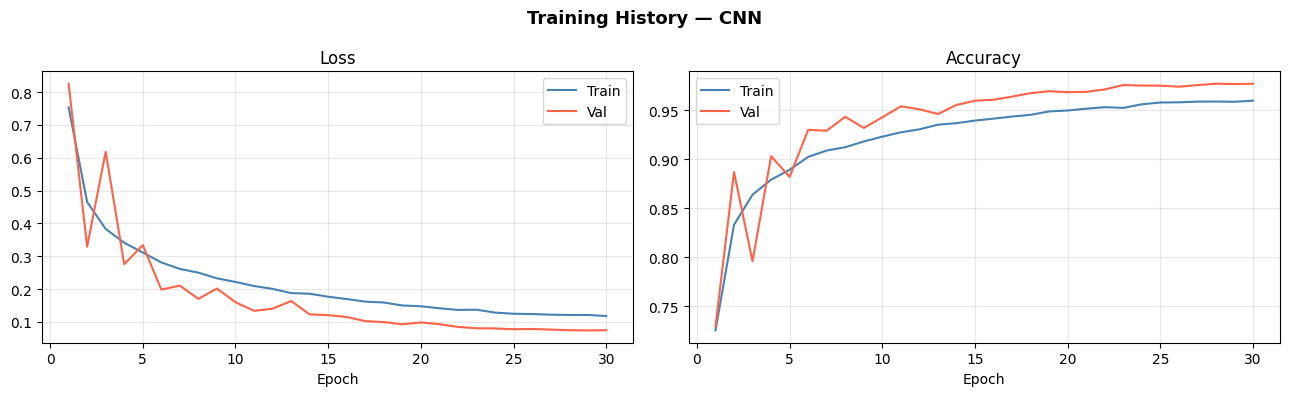

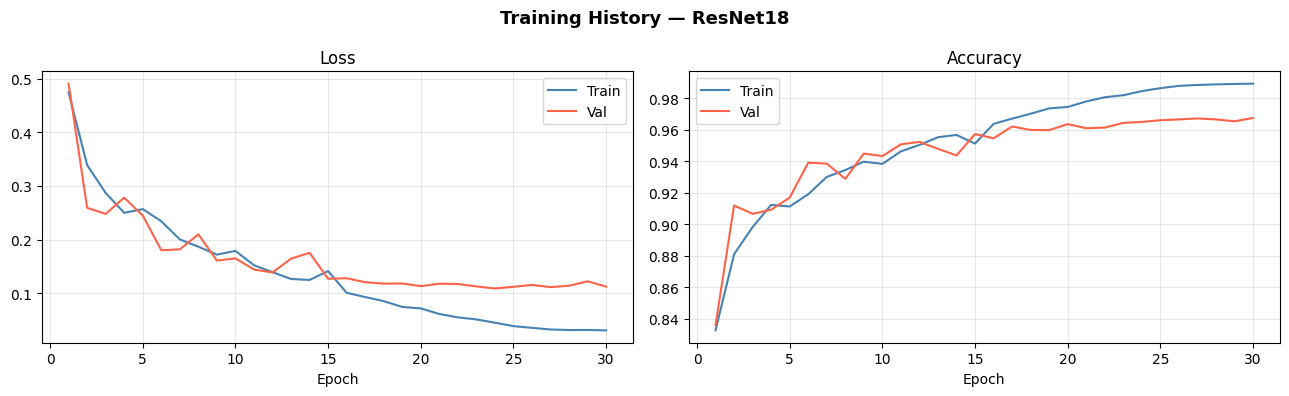

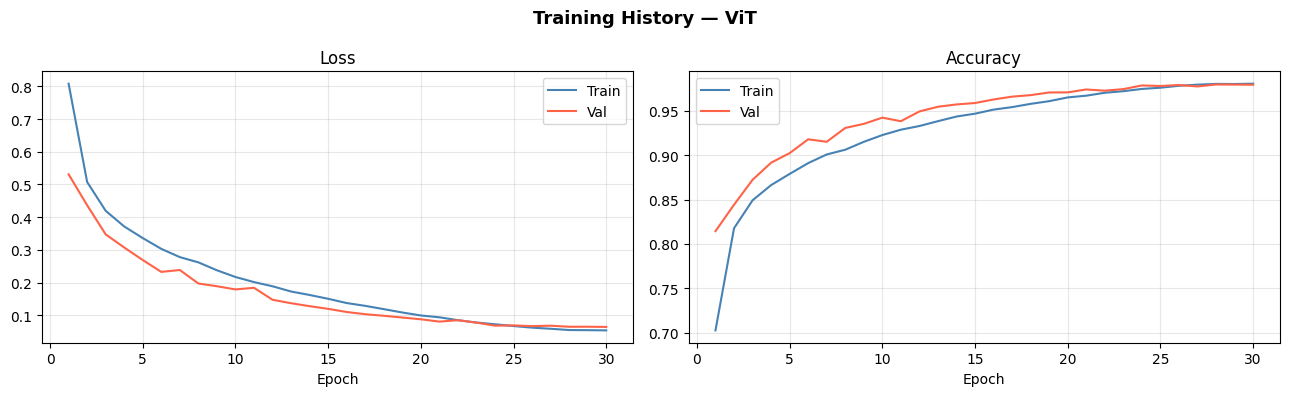

In [18]:
def plot_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Training History — {model_name}', fontsize=13, fontweight='bold')

    ax1.plot(epochs, history['train_loss'], label='Train', color='steelblue')
    ax1.plot(epochs, history['val_loss'],   label='Val',   color='tomato')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train', color='steelblue')
    ax2.plot(epochs, history['val_acc'],   label='Val',   color='tomato')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_curves(cnn_history,    'CNN')
plot_curves(resnet_history, 'ResNet18')
plot_curves(vit_history,    'ViT')

## 10. Evaluate trên tập Test

In [19]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    preds, trues = [], []
    for images, labels in loader:
        out = model(images.to(DEVICE)).argmax(1).cpu().numpy()
        preds.append(out)
        trues.append(labels.squeeze(1).numpy())
    return np.concatenate(preds), np.concatenate(trues)


def load_best(model, model_name):
    model.load_state_dict(torch.load(f'{CKPT_DIR}/{model_name}_best.pth', map_location=DEVICE))
    return model


def full_eval(model, model_name):
    model = load_best(model, model_name)
    preds, trues = predict_all(model, test_loader)

    metrics = dict(
        accuracy  = accuracy_score(trues, preds),
        precision = precision_score(trues, preds, average='macro', zero_division=0),
        recall    = recall_score(trues, preds, average='macro', zero_division=0),
        f1_score  = f1_score(trues, preds, average='macro', zero_division=0),
    )

    print(f'\n{"="*55}')
    print(f'  KẾT QUẢ TEST: {model_name.upper()}')
    print(f'{"="*55}')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f} ({v*100:.2f}%)')
    print()
    print(classification_report(trues, preds, target_names=CLASS_NAMES, zero_division=0))

    return metrics, confusion_matrix(trues, preds), preds, trues


cnn_metrics,    cnn_cm,    cnn_preds,    cnn_trues    = full_eval(cnn_model,    'cnn')
resnet_metrics, resnet_cm, resnet_preds, resnet_trues = full_eval(resnet_model, 'resnet18')
vit_metrics,    vit_cm,    vit_preds,    vit_trues    = full_eval(vit_model,    'vit')


  KẾT QUẢ TEST: CNN
  accuracy    : 0.9219 (92.19%)
  precision   : 0.9077 (90.77%)
  recall      : 0.8892 (88.92%)
  f1_score    : 0.8903 (89.03%)

                           precision    recall  f1-score   support

                  Adipose       0.95      1.00      0.97      1338
               Background       0.90      1.00      0.95       847
                   Debris       0.77      0.89      0.82       339
              Lymphocytes       0.94      1.00      0.97       634
                    Mucus       0.98      0.89      0.94      1035
            Smooth Muscle       0.83      0.84      0.83       592
      Normal Colon Mucosa       0.97      0.93      0.95       741
     Cancer-Assoc. Stroma       0.91      0.49      0.64       421
Colorectal Adenocarcinoma       0.92      0.96      0.94      1233

                 accuracy                           0.92      7180
                macro avg       0.91      0.89      0.89      7180
             weighted avg       0.92      0.

## 11. Confusion Matrix

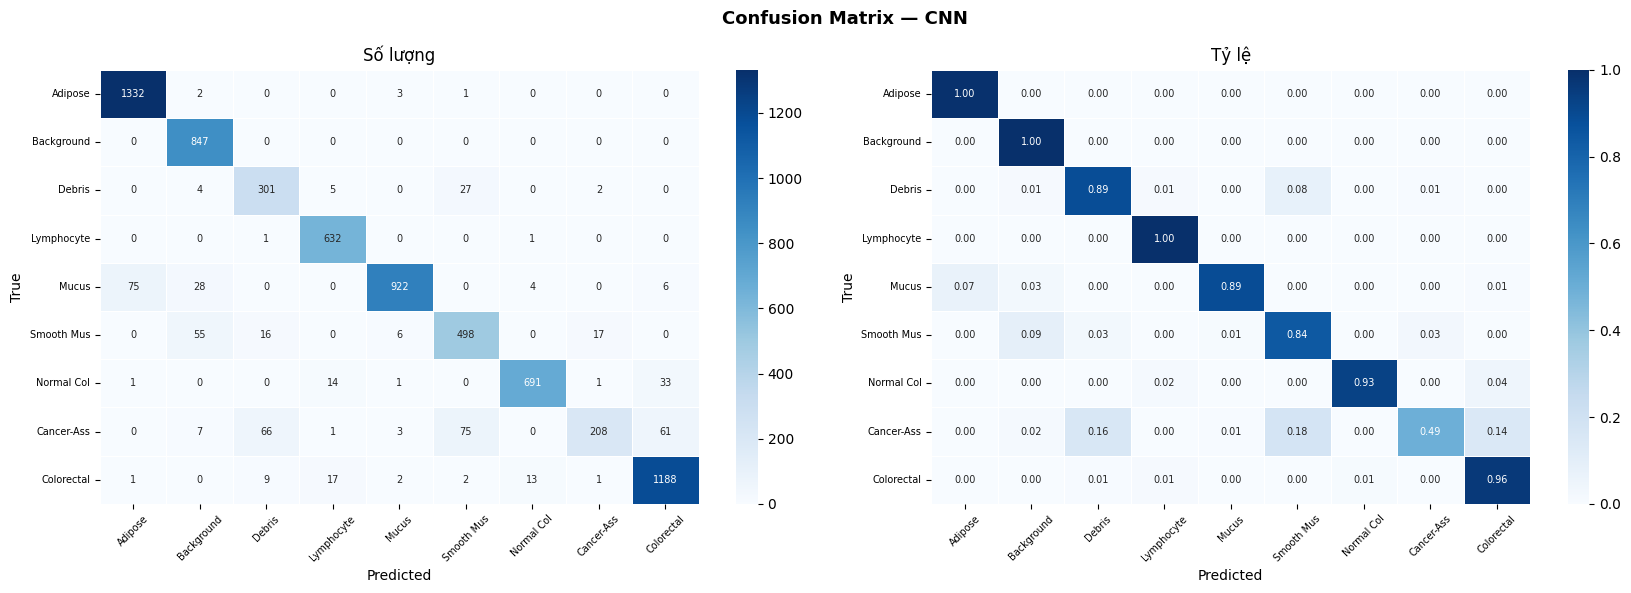

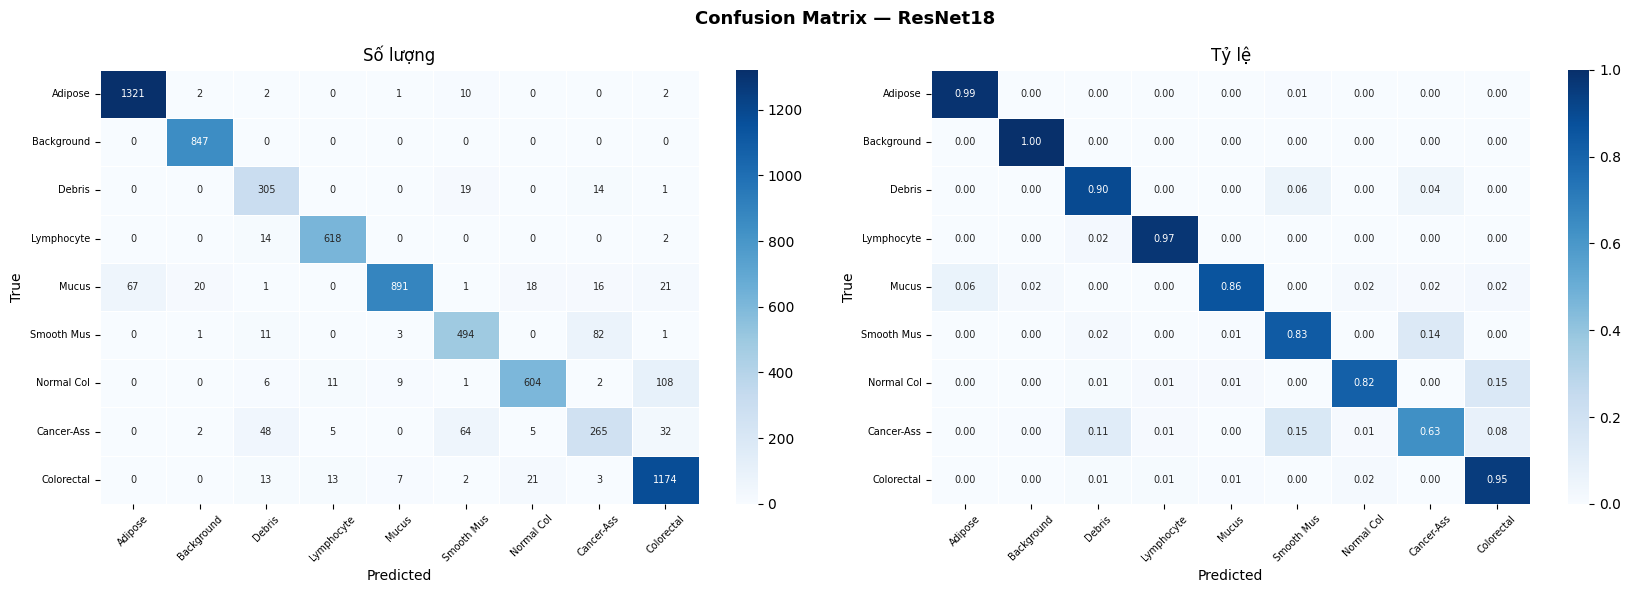

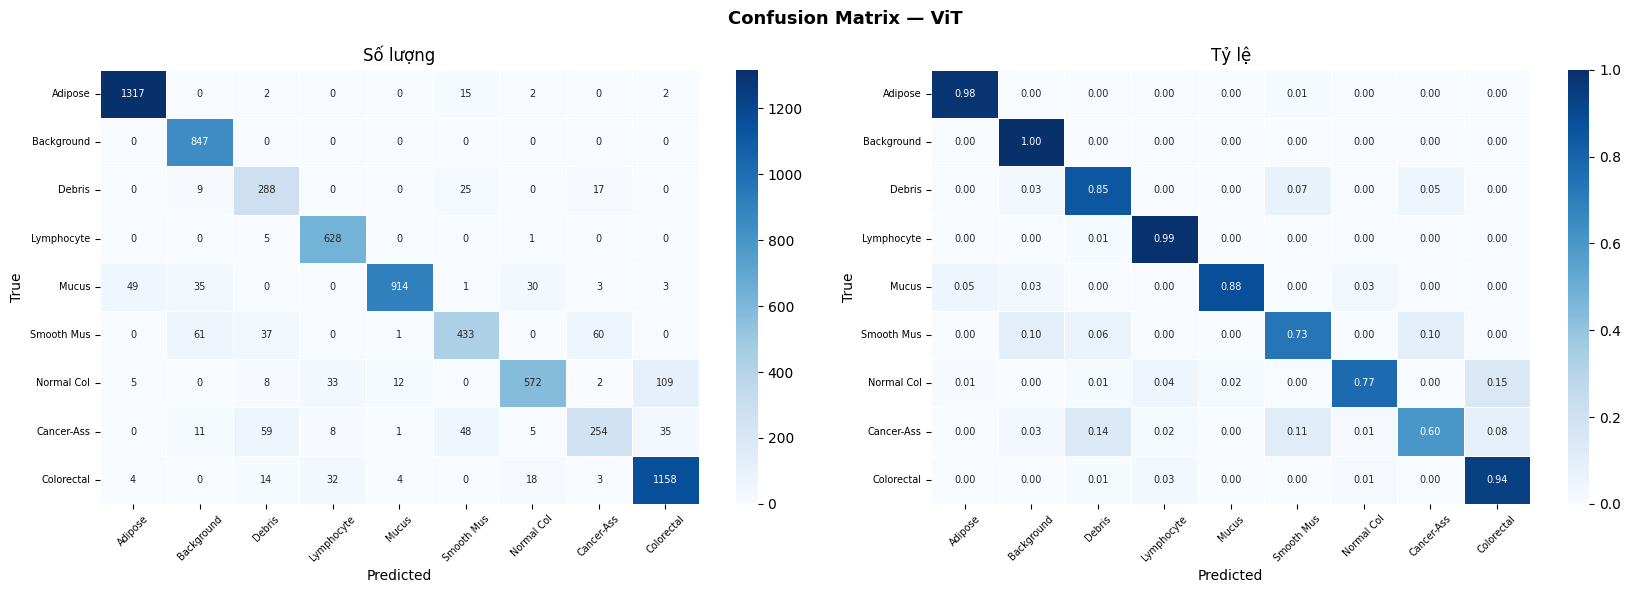

In [20]:
def plot_cm(cm, model_name):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short   = [n[:10] for n in CLASS_NAMES]

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')

    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ['Số lượng', 'Tỷ lệ'], ['d', '.2f']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=short, yticklabels=short, ax=ax,
                    linewidths=0.4, annot_kws={'size': 7})
        ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)

    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_cm(cnn_cm,    'CNN')
plot_cm(resnet_cm, 'ResNet18')
plot_cm(vit_cm,    'ViT')

## 12. Bảng so sánh tổng hợp


  BẢNG SO SÁNH TỔNG HỢP (Test Set)
  Model         Accuracy  Precision   Recall       F1
  ----------------------------------------------------
  CNN             0.9219     0.9077   0.8892   0.8903
  ResNet18        0.9079     0.8840   0.8838   0.8820
  ViT             0.8929     0.8652   0.8615   0.8596


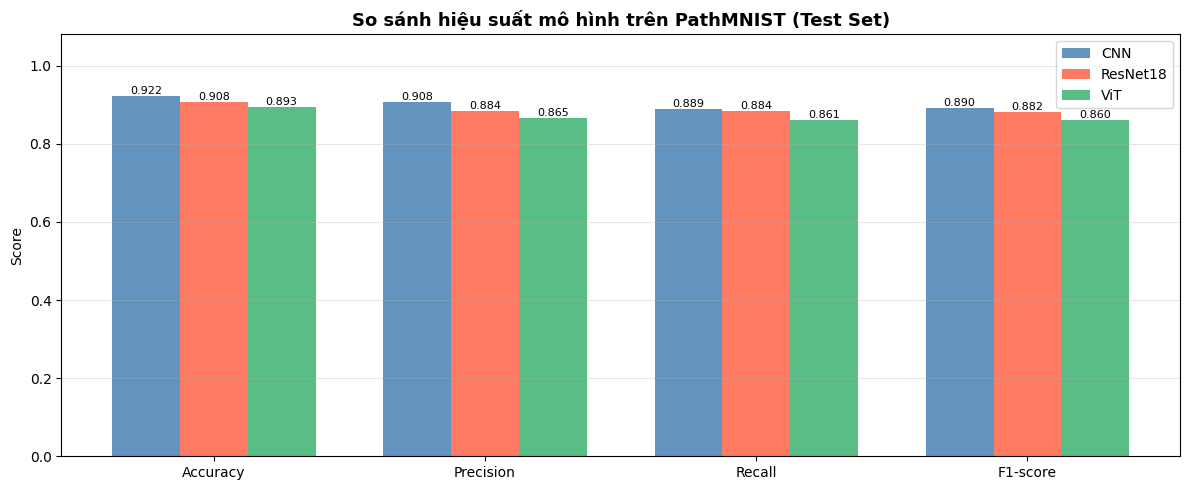


Kết quả đã lưu: /content/drive/MyDrive/PathMNIST_Results/results/metrics_summary.json


In [21]:
all_results = {
    'CNN':      cnn_metrics,
    'ResNet18': resnet_metrics,
    'ViT':      vit_metrics,
}

# Bảng text
print(f"\n{'='*60}")
print('  BẢNG SO SÁNH TỔNG HỢP (Test Set)')
print(f"{'='*60}")
print(f"  {'Model':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*52}")
for name, m in all_results.items():
    print(f"  {name:<12} {m['accuracy']:>9.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>8.4f} {m['f1_score']:>8.4f}")

# Biểu đồ so sánh
metric_keys   = ['accuracy', 'precision', 'recall', 'f1_score']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
model_names   = list(all_results.keys())
colors        = ['steelblue', 'tomato', 'mediumseagreen']

x = np.arange(len(metric_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [all_results[name][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8)

ax.set_title('So sánh hiệu suất mô hình trên PathMNIST (Test Set)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.08); ax.set_ylabel('Score')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Lưu JSON
with open(f'{RESULTS_DIR}/metrics_summary.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\nKết quả đã lưu: {RESULTS_DIR}/metrics_summary.json')

## 13. Grad-CAM — Giải thích mô hình CNN

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


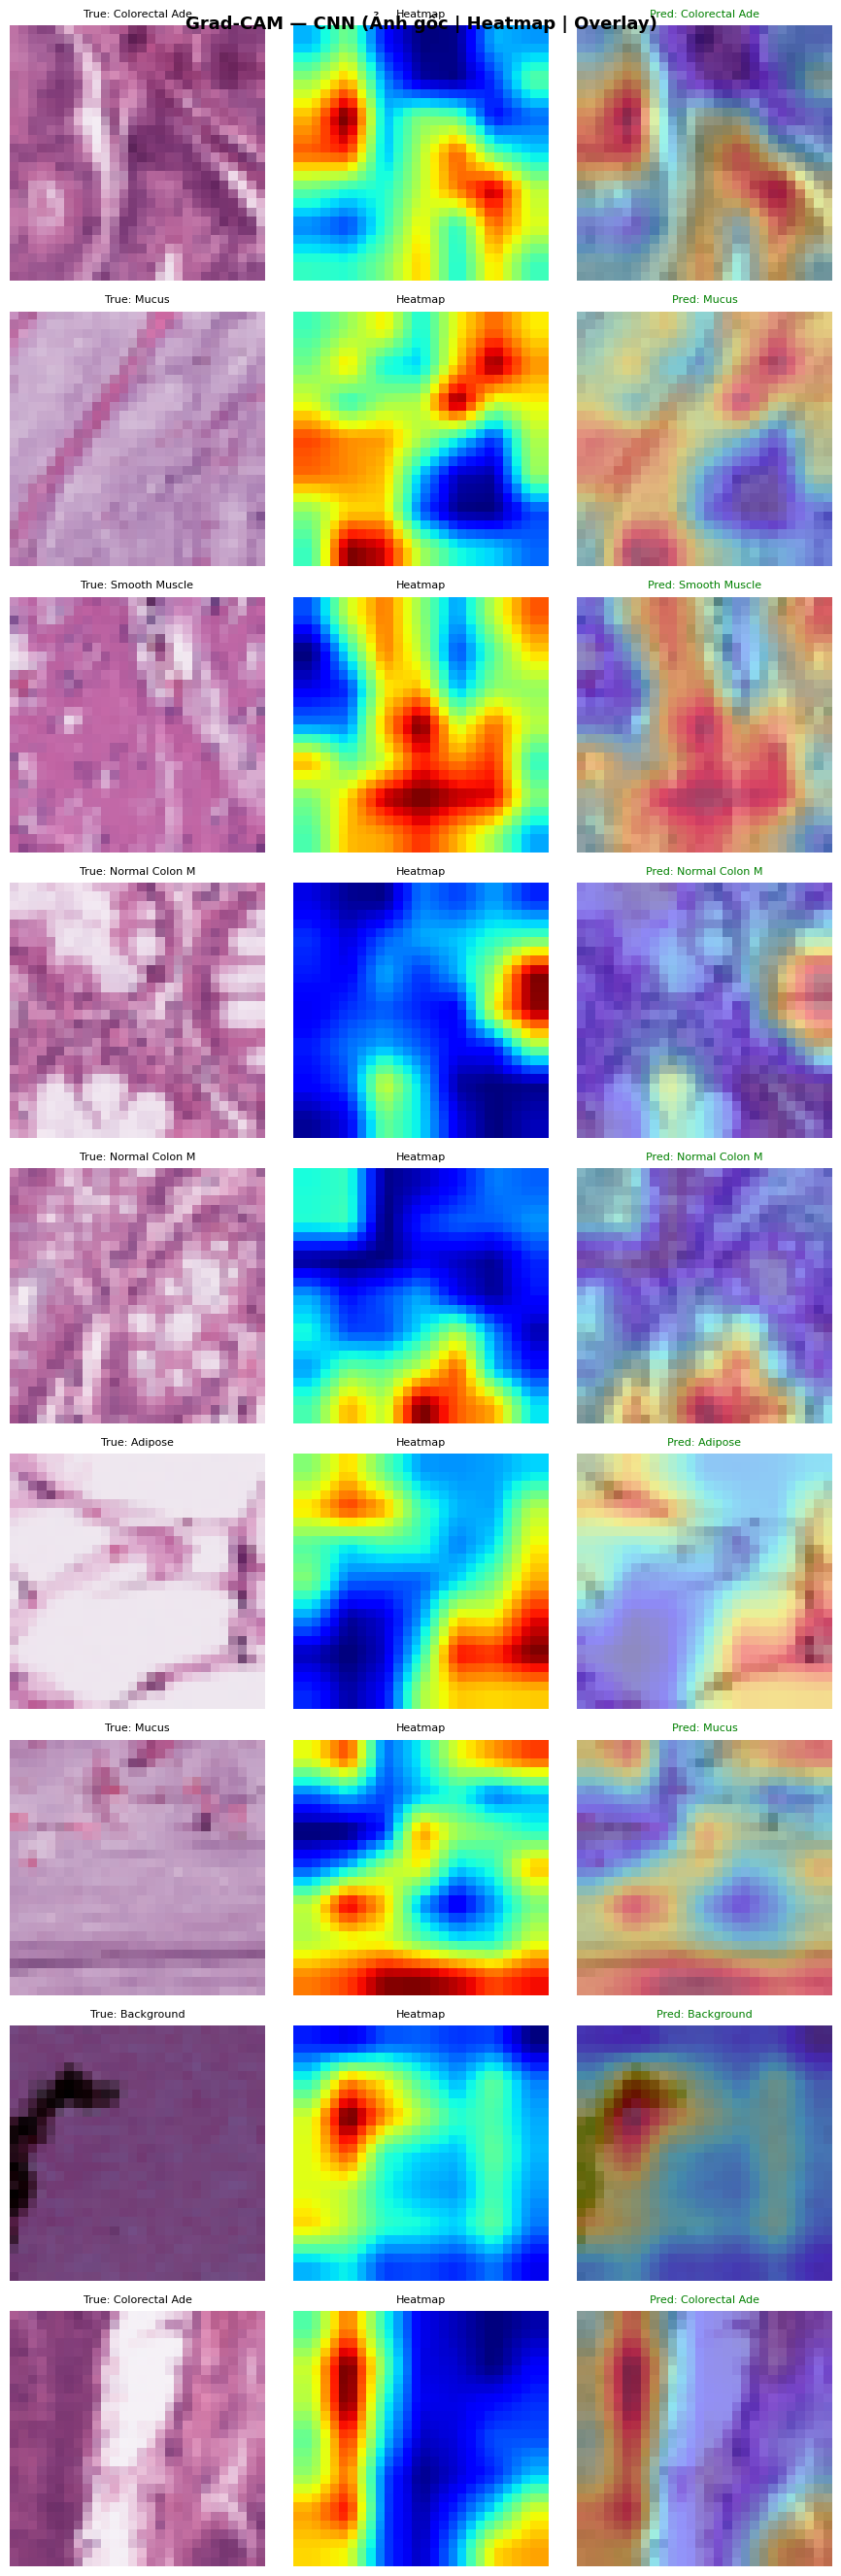

[Saved] /content/drive/MyDrive/PathMNIST_Results/figures/gradcam_cnn.png


In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = self.acts = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        target_layer.register_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def generate(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        w   = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


# Lấy target layer: block cuối của CNN
best_cnn = load_best(cnn_model, 'cnn')
target_layer = best_cnn.features[-1].block[1]  # BatchNorm sau Conv cuối
gradcam = GradCAM(best_cnn, target_layer)

# Lấy mẫu test
test_ds_raw = PathMNIST(split='test', transform=get_transforms('test'),
                         download=True, root=DATA_DIR, size=28)
MEAN_T = torch.tensor(MEAN).view(3,1,1)
STD_T  = torch.tensor(STD).view(3,1,1)

n_samples = 9
indices   = list(range(0, len(test_ds_raw), len(test_ds_raw) // n_samples))[:n_samples]

fig, axes = plt.subplots(n_samples, 3, figsize=(9, n_samples * 3))
fig.suptitle('Grad-CAM — CNN (Ảnh gốc | Heatmap | Overlay)', fontsize=13, fontweight='bold')

for row, idx in enumerate(indices):
    img_t, label = test_ds_raw[idx]
    label = label.item() if hasattr(label, 'item') else int(label)

    inp = img_t.unsqueeze(0).to(DEVICE)
    heatmap = gradcam.generate(inp)

    img_show = (img_t * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
    overlay  = mpl_cm.jet(heatmap)[...,:3] * 0.4 + img_show * 0.6

    with torch.no_grad():
        pred = best_cnn(inp).argmax(1).item()

    axes[row][0].imshow(img_show);      axes[row][0].axis('off')
    axes[row][0].set_title(f'True: {CLASS_NAMES[label][:14]}', fontsize=8)
    axes[row][1].imshow(heatmap, cmap='jet'); axes[row][1].axis('off')
    axes[row][1].set_title('Heatmap', fontsize=8)
    axes[row][2].imshow(overlay);       axes[row][2].axis('off')
    axes[row][2].set_title(f'Pred: {CLASS_NAMES[pred][:14]}', fontsize=8,
                            color='green' if pred == label else 'red')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/gradcam_cnn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[Saved] {FIGURE_DIR}/gradcam_cnn.png')

## 14. Tổng kết & Liệt kê file đã lưu

In [23]:
import glob

print('=' * 55)
print('  KẾT QUẢ CUỐI CÙNG')
print('=' * 55)
print(f"  {'Model':<12} {'Accuracy':>9} {'F1-score':>10}")
print(f"  {'-'*35}")
for name, m in all_results.items():
    print(f"  {name:<12} {m['accuracy']*100:>8.2f}%  {m['f1_score']*100:>9.2f}%")

print('\n  FILES ĐÃ LƯU VÀO DRIVE:')
for f in sorted(glob.glob(f'{DRIVE_DIR}/**/*', recursive=True)):
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1e6
        print(f"  {f.replace(DRIVE_DIR, '')}  ({size:.1f} MB)")

  KẾT QUẢ CUỐI CÙNG
  Model         Accuracy   F1-score
  -----------------------------------
  CNN             92.19%      89.03%
  ResNet18        90.79%      88.20%
  ViT             89.29%      85.96%

  FILES ĐÃ LƯU VÀO DRIVE:
  /checkpoints/cnn_best.pth  (0.5 MB)
  /checkpoints/resnet18_best.pth  (44.8 MB)
  /checkpoints/vit_best.pth  (4.8 MB)
  /figures/CNN_confusion_matrix.png  (0.1 MB)
  /figures/CNN_curves.png  (0.1 MB)
  /figures/ResNet18_confusion_matrix.png  (0.1 MB)
  /figures/ResNet18_curves.png  (0.1 MB)
  /figures/ViT_confusion_matrix.png  (0.1 MB)
  /figures/ViT_curves.png  (0.1 MB)
  /figures/eda_label_distribution.png  (0.1 MB)
  /figures/eda_pixel_distribution.png  (0.1 MB)
  /figures/eda_sample_images.png  (0.2 MB)
  /figures/gradcam_cnn.png  (0.2 MB)
  /figures/model_comparison.png  (0.0 MB)
  /results/metrics_summary.json  (0.0 MB)
